In [1]:
#Import Libs
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from scipy.spatial import *

In [2]:
# Datasets
url_lenna = 'https://raw.githubusercontent.com/jrafa1607/Evaluation-of-Perceptual-Hash-Algorithms/main/Hamming%20Distance%20Values/lennadatabase.csv'
url_mountain = 'https://raw.githubusercontent.com/jrafa1607/Evaluation-of-Perceptual-Hash-Algorithms/main/Hamming%20Distance%20Values/mountaindatabase.csv'
url_palace = 'https://raw.githubusercontent.com/jrafa1607/Evaluation-of-Perceptual-Hash-Algorithms/main/Hamming%20Distance%20Values/palacedatabase.csv'
url_park = 'https://raw.githubusercontent.com/jrafa1607/Evaluation-of-Perceptual-Hash-Algorithms/main/Hamming%20Distance%20Values/parkdatabase.csv'
url_washington = 'https://raw.githubusercontent.com/jrafa1607/Evaluation-of-Perceptual-Hash-Algorithms/main/Hamming%20Distance%20Values/washingtondatabase.csv'

In [3]:
# Import Datasets
lenna = pd.read_csv(url_lenna, delimiter=';', encoding='unicode_escape')
mountain = pd.read_csv(url_mountain, delimiter=';', encoding='unicode_escape')
palace = pd.read_csv(url_palace, delimiter=';', encoding='unicode_escape')
park = pd.read_csv(url_park, delimiter=';', encoding='unicode_escape')
washington = pd.read_csv(url_washington, delimiter=';', encoding='unicode_escape')

### **Image Databases Description**

Below are the available image databases. Please choose one when prompted:

*   **Lenna Database**: Contains 20 images for analysis. Often used for general image processing tests.
*   **Mountain Database**: Comprises 30 images, possibly related to landscape or outdoor scenes.
*   **Palace Database**: Includes 31 images, likely focused on architectural or historical structures.
*   **Park Database**: Consists of 11 images, potentially showcasing park scenes or natural environments.
*   **Washington Database**: Features 7 images, which might be specific to the Washington D.C. area or a particular dataset.

In [4]:
# Select the Dataset to Start the Calculations
print("Available Databases:")
print("1. Lenna Database (20 images)")
print("2. Mountain Database (30 images)")
print("3. Palace Database (31 images)")
print("4. Park Database (11 images)")
print("5. Washington Database (7 images)")

while True:
    choice = input("Enter the number corresponding to the database you want to use: ")
    if choice == '1':
        df = lenna
        total = 20
        print("\nLenna Database selected.")
        break
    elif choice == '2':
        df = mountain
        total = 30
        print("\nMountain Database selected.")
        break
    elif choice == '3':
        df = palace
        total = 31
        print("\nPalace Database selected.")
        break
    elif choice == '4':
        df = park
        total = 11
        print("\nPark Database selected.")
        break
    elif choice == '5':
        df = washington
        total = 7
        print("\nWashington Database selected.")
        break
    else:
        print("\nInvalid choice. Please enter a number between 1 and 5.")

print(f"You have selected a database with {total} images.")

Available Databases:
1. Lenna Database (20 images)
2. Mountain Database (30 images)
3. Palace Database (31 images)
4. Park Database (11 images)
5. Washington Database (7 images)
Enter the number corresponding to the database you want to use: 1

Lenna Database selected.
You have selected a database with 20 images.


In [5]:
#Select All the Values to the Variables
ahash = df['A. Hash Hamming']
phash = df['P. Hash Hamming']
dhash = df['D. Hash Hamming']
whash = df['W. Hash Hamming']
cphash = df['CP Hash Hamming']

In [6]:
#Add a Original Array
Original_array = []

for i in range(total):
    Original_array.append(0)

In [7]:
#Function to Calc: Euclidean Distance and Manhattan Distance
def distance_Calc(array,algorithm):
    dst_euclid = distance.euclidean(Original_array, array)
    dst_manh = distance.cityblock(Original_array, array)

    print("\nHash Perceptual Algorithm: " + str(algorithm))
    print("Euclidean Distance Value: " + str(dst_euclid))
    print("Manhattan Distance Value: " + str(dst_manh))

In [8]:
#Results for All Distances
distance_Calc(ahash, "Average Hashing")
distance_Calc(phash, "Perceptual Hashing")
distance_Calc(dhash, "Difference Hashing")
distance_Calc(whash, "Wavelet Hashing")
distance_Calc(cphash, "Crop-Resistant Hashing")


Hash Perceptual Algorithm: Average Hashing
Euclidean Distance Value: 24.49489742783178
Manhattan Distance Value: 56

Hash Perceptual Algorithm: Perceptual Hashing
Euclidean Distance Value: 23.664319132398465
Manhattan Distance Value: 52

Hash Perceptual Algorithm: Difference Hashing
Euclidean Distance Value: 17.86057109949175
Manhattan Distance Value: 37

Hash Perceptual Algorithm: Wavelet Hashing
Euclidean Distance Value: 22.20360331117452
Manhattan Distance Value: 47

Hash Perceptual Algorithm: Crop-Resistant Hashing
Euclidean Distance Value: 36.681120484521735
Manhattan Distance Value: 109.92


### **Minkowski Distance**

The Minkowski Distance is a generalized metric used to measure the distance between two points in a normalized vector space (p-space).

It is defined by the formula:

$D(\mathbf{x}, \mathbf{y}) = (\sum_{i=1}^{n} |x_i - y_i|^p)^{1/p}$

Where:
*   $x$ and $y$ are the two vectors to be compared.
*   $p$ is the order parameter.
*   $n$ is the dimension of the vectors.

#### **Relationship with other distances:**

The Minkowski Distance can be specialized for different values of $p$:

*   **When $p = 1$ (Manhattan Distance):**
    The formula simplifies to: $D(\mathbf{x}, \mathbf{y}) = \sum_{i=1}^{n} |x_i - y_i|$.
    This is known as Manhattan Distance, or city-block distance, which calculates the sum of the absolute differences between the coordinates.

*   **When $p = 2$ (Euclidean Distance):**
    The formula becomes: $D(\mathbf{x}, \mathbf{y}) = (\sum_{i=1}^{n} (x_i - y_i)^2)^{1/2}$.
    This is the Euclidean Distance, the straight-line distance between two points, familiar from the Pythagorean theorem.

In [9]:
#Minkovski Distance Calc
dst_mink1= distance.minkowski(Original_array, ahash, 1)
dst_mink2= distance.minkowski(Original_array, ahash, 2)

print(dst_mink1)
print(dst_mink2)

56.0
24.49489742783178


In [10]:
# Prepare data for Euclidean and Manhattan distances Graphs
hash_algorithms = ["Average Hashing", "Perceptual Hashing", "Difference Hashing", "Wavelet Hashing", "Crop-Resistant Hashing"]
hash_series = [ahash, phash, dhash, whash, cphash]

euclidean_distances = []
manhattan_distances = []

for hs in hash_series:
    euclidean_distances.append(distance.euclidean(Original_array, hs))
    manhattan_distances.append(distance.cityblock(Original_array, hs))

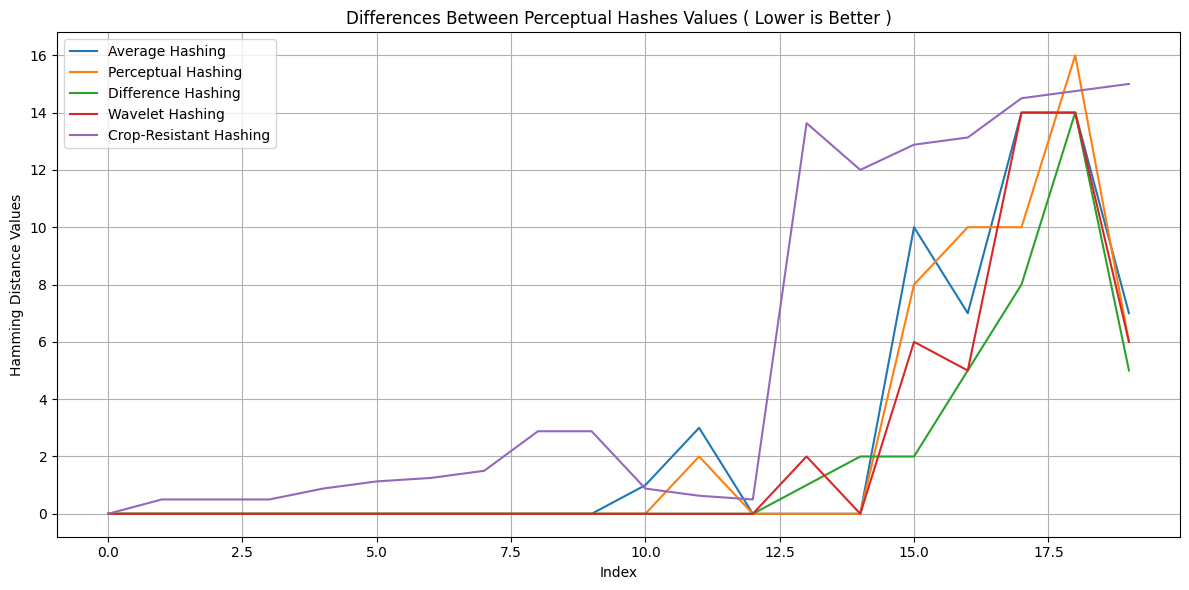

In [11]:
# Show the Differences Between Perceptual Hashes Values
plt.figure(figsize=(12, 6))
for i, hs in enumerate(hash_series):
    plt.plot(hs.index, hs.values, label=hash_algorithms[i])
plt.title('Differences Between Perceptual Hashes Values ( Lower is Better )')
plt.xlabel('Index')
plt.ylabel('Hamming Distance Values')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

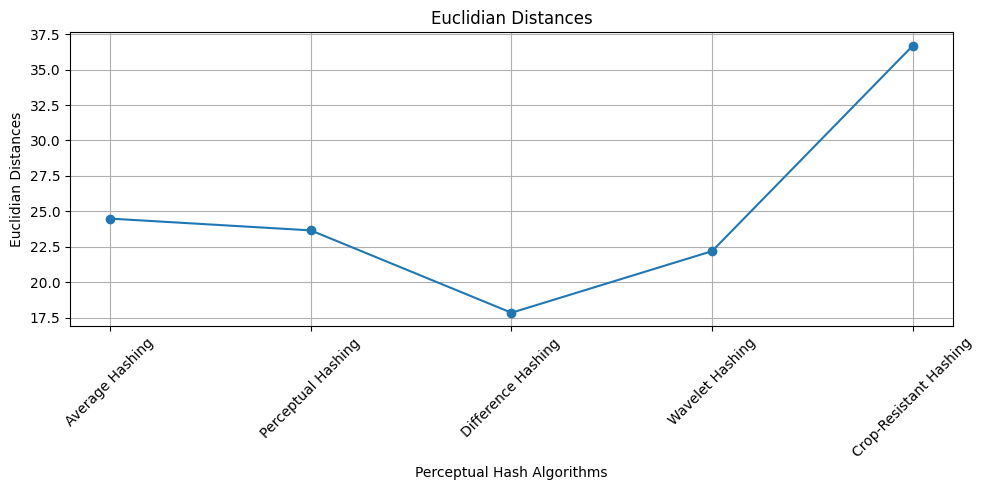

In [12]:
# Show the Euclidean Distances
plt.figure(figsize=(10, 5))
plt.plot(hash_algorithms, euclidean_distances, marker='o', linestyle='-')
plt.title('Euclidian Distances')
plt.xlabel('Perceptual Hash Algorithms')
plt.ylabel('Euclidian Distances')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

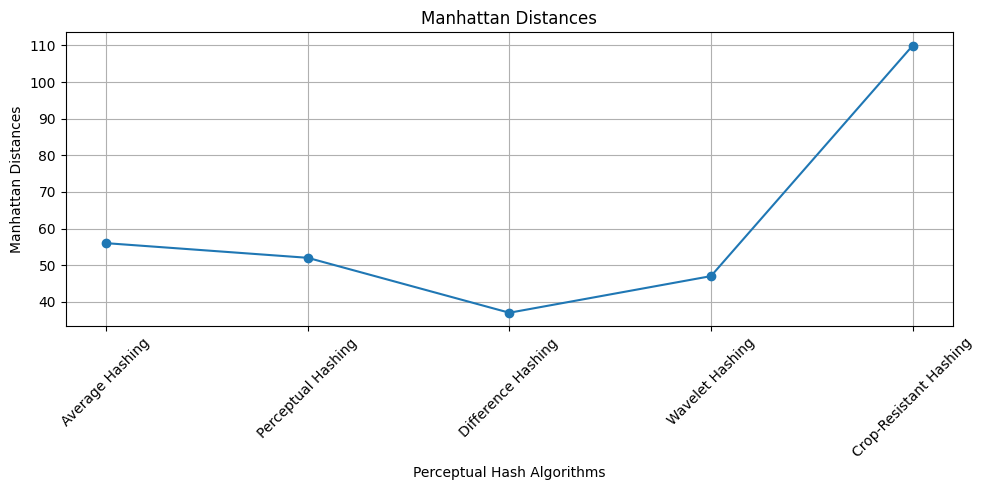

In [13]:
# Show the Manhattan distances
plt.figure(figsize=(10, 5))
plt.plot(hash_algorithms, manhattan_distances, marker='o', linestyle='-')
plt.title('Manhattan Distances')
plt.xlabel('Perceptual Hash Algorithms')
plt.ylabel('Manhattan Distances')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

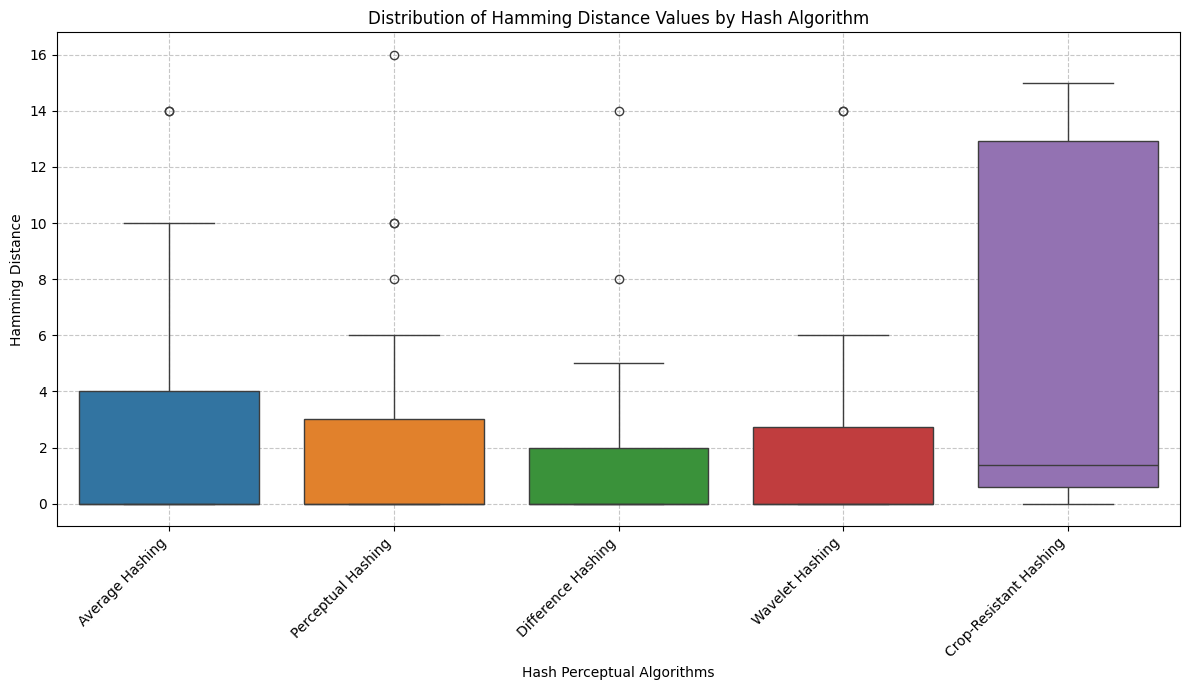

In [14]:
# Show the BoxPlot of All Perceptual Hash Algorithms
hash_data_for_boxplot = pd.DataFrame({
    'Average Hashing': ahash,
    'Perceptual Hashing': phash,
    'Difference Hashing': dhash,
    'Wavelet Hashing': whash,
    'Crop-Resistant Hashing': cphash
})

plt.figure(figsize=(12, 7))
sns.boxplot(data=hash_data_for_boxplot)
plt.title('Distribution of Hamming Distance Values by Hash Algorithm')
plt.xlabel('Hash Perceptual Algorithms')
plt.ylabel('Hamming Distance')
plt.xticks(rotation=45, ha='right')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()